# Wine Quality Classification with SVM

This notebook predicts wine quality category (**low / medium / high**) from four physicochemical
measurements using a Support Vector Machine (SVM) classifier.

**Improvements over the original notebook:**
- Full exploratory data analysis (EDA) with visualizations
- Data cleaning checks (missing values, duplicates, outliers)
- Feature engineering (two extra derived features)
- Proper preprocessing pipeline (scaling fit only on training data)
- Stratified train/test split
- Hyperparameter tuning with `GridSearchCV` + stratified cross-validation
- Full evaluation suite: accuracy, precision, recall, F1 (macro & weighted), confusion matrix
- A baseline comparison so the SVM's performance can be judged in context
- A saved, reusable prediction function


In [1]:
# 1. Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42


## 2. Load the data

In [2]:
df = pd.read_csv('wine_quality_classification.csv')
print("Shape:", df.shape)
df.head()


Shape: (1000, 5)


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   fixed_acidity   1000 non-null   float64
 1   residual_sugar  1000 non-null   float64
 2   alcohol         1000 non-null   float64
 3   density         1000 non-null   float64
 4   quality_label   1000 non-null   str    
dtypes: float64(4), str(1)
memory usage: 39.2 KB


## 3. Data cleaning checks

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nClass balance:")
print(df['quality_label'].value_counts())
print("\nSummary statistics:")
df.describe()


Missing values per column:
fixed_acidity     0
residual_sugar    0
alcohol           0
density           0
quality_label     0
dtype: int64

Duplicate rows: 0

Class balance:
quality_label
medium    355
high      343
low       302
Name: count, dtype: int64

Summary statistics:


In [5]:
# Drop exact duplicate rows if any exist (none found in this dataset, but kept for robustness)
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate row(s). New shape: {df.shape}")


Removed 0 duplicate row(s). New shape: (1000, 5)


In [6]:
# Outlier check using the IQR rule (reporting only — the physicochemical ranges here
# are realistic, so we don't blindly drop points, just confirm nothing is broken)
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

numeric_cols = ['fixed_acidity', 'residual_sugar', 'alcohol', 'density']
for col in numeric_cols:
    print(f"{col}: {iqr_outlier_count(df[col])} potential outliers (IQR rule)")


fixed_acidity: 0 potential outliers (IQR rule)
residual_sugar: 0 potential outliers (IQR rule)
alcohol: 0 potential outliers (IQR rule)
density: 0 potential outliers (IQR rule)


## 4. Exploratory visualizations

### 4.1 Class distribution

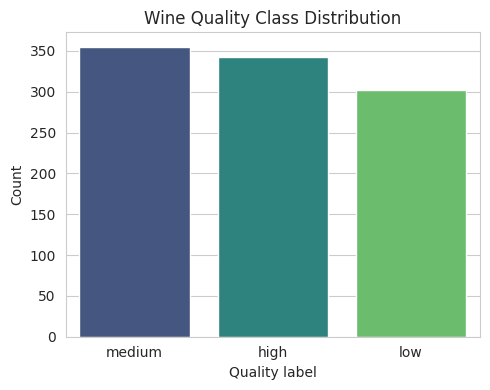

In [7]:
plt.figure(figsize=(5, 4))
order = df['quality_label'].value_counts().index
sns.countplot(data=df, x='quality_label', order=order, palette='viridis')
plt.title('Wine Quality Class Distribution')
plt.xlabel('Quality label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### 4.2 Feature distributions

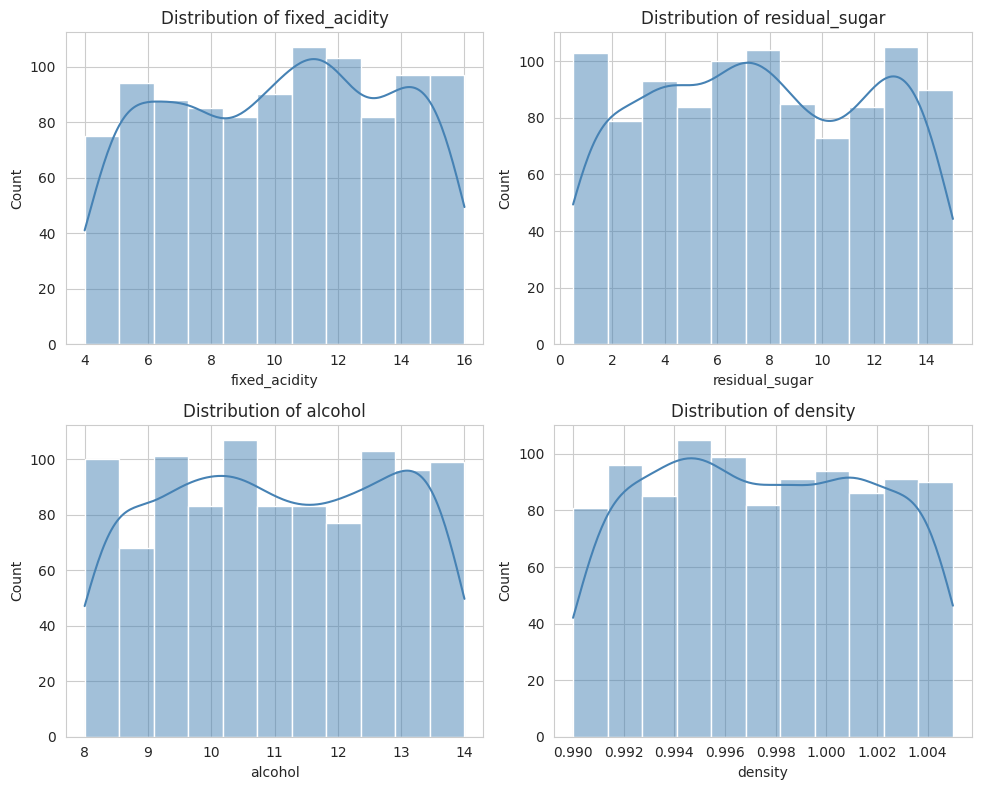

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


### 4.3 Feature spread by quality label

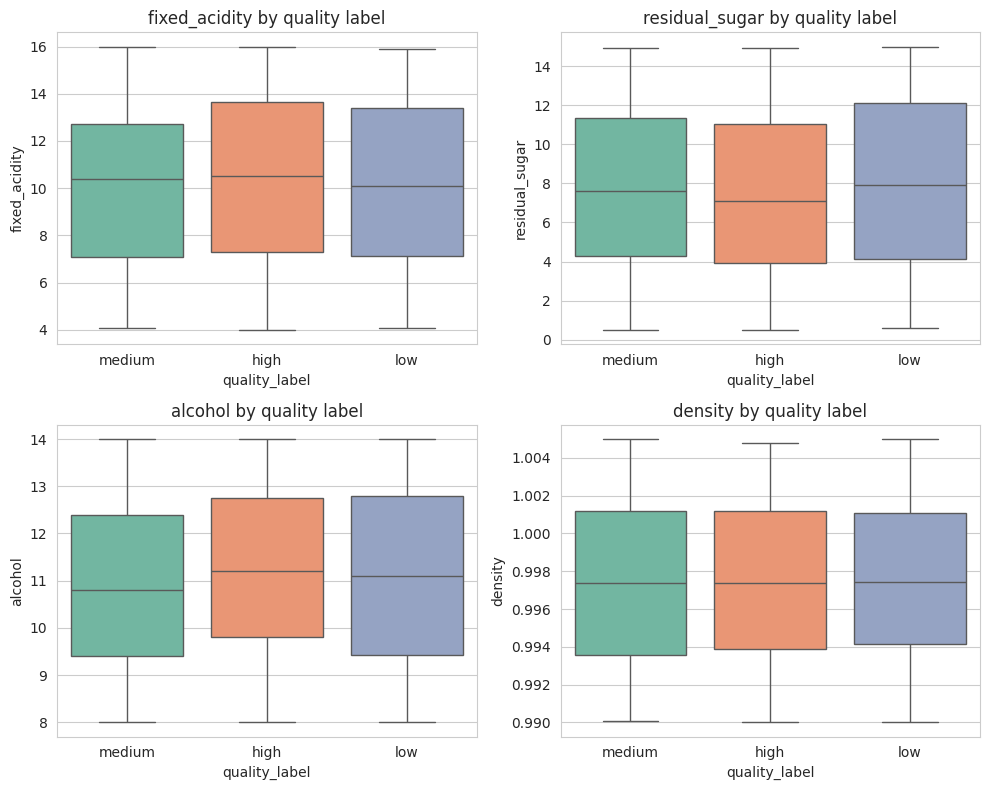

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=df, x='quality_label', y=col, order=order, ax=ax, palette='Set2')
    ax.set_title(f'{col} by quality label')
plt.tight_layout()
plt.show()


### 4.4 Correlation heatmap

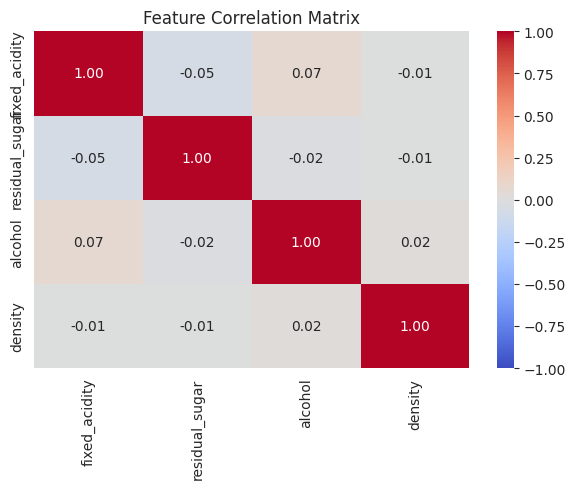

In [10]:
plt.figure(figsize=(6, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


### 4.5 Pairwise relationships

This view makes it easy to see whether the three quality classes form visually separable
clusters in feature space.

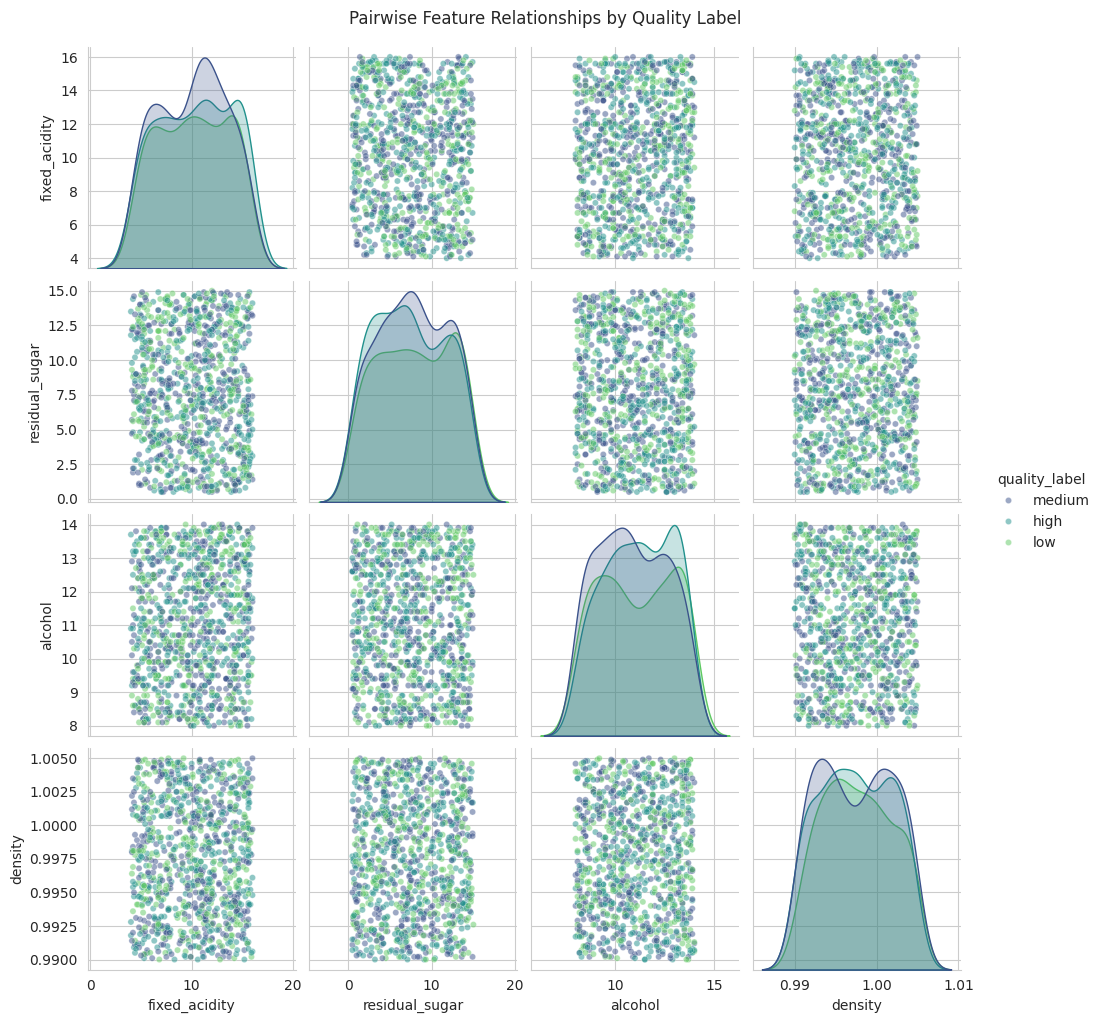

In [11]:
sns.pairplot(df, vars=numeric_cols, hue='quality_label', hue_order=order,
             palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairwise Feature Relationships by Quality Label', y=1.02)
plt.show()


**Observation:** the box plots, correlation matrix, and pairplot all show heavy overlap
between the `low` / `medium` / `high` classes across every feature, and the correlation between
the four measurements is very weak. This is useful context for interpreting the model scores
in Section 7 — it tells us the *ceiling* on achievable accuracy is limited by the data itself,
not just by model choice.

## 5. Feature engineering & preprocessing

In [12]:
# A couple of simple derived features — ratios and interactions sometimes expose
# non-linear structure that raw measurements don't show on their own.
df['sugar_acid_ratio'] = df['residual_sugar'] / df['fixed_acidity']
df['alcohol_density_interaction'] = df['alcohol'] * df['density']

feature_cols = numeric_cols + ['sugar_acid_ratio', 'alcohol_density_interaction']

le = LabelEncoder()
df['quality_encoded'] = le.fit_transform(df['quality_label'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df[feature_cols]
y = df['quality_encoded']


Label mapping: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


In [13]:
# Stratified split keeps the same class proportions in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Fit the scaler ONLY on the training data to avoid leaking test-set information
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, " Test shape:", X_test_scaled.shape)


Train shape: (800, 6)  Test shape: (200, 6)


## 6. Baseline model

Before tuning the SVM, we check what a trivial classifier (always predicting the most common
class) would score. Any real model needs to clearly beat this to be considered useful.

In [14]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train_scaled, y_train)
dummy_pred = dummy.predict(X_test_scaled)
print("Baseline ('always predict most frequent class') accuracy:", accuracy_score(y_test, dummy_pred))


Baseline ('always predict most frequent class') accuracy: 0.355


## 7. SVM with hyperparameter tuning

In [15]:
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    SVC(random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validated F1 (macro):", round(grid_search.best_score_, 4))

svm_model = grid_search.best_estimator_


Best hyperparameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validated F1 (macro): 0.3694


In [16]:
y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')
precision_weighted = precision_score(y_test, y_pred, average='weighted')
recall_weighted = recall_score(y_test, y_pred, average='weighted')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy:            {accuracy:.4f}")
print(f"Precision (macro):    {precision_macro:.4f}")
print(f"Recall (macro):       {recall_macro:.4f}")
print(f"F1-score (macro):     {f1_macro:.4f}")
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted):    {recall_weighted:.4f}")
print(f"F1-score (weighted):  {f1_weighted:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy:            0.3250
Precision (macro):    0.3198
Recall (macro):       0.3243
F1-score (macro):     0.3188
Precision (weighted): 0.3187
Recall (weighted):    0.3250
F1-score (weighted):  0.3185

Full classification report:
              precision    recall  f1-score   support

        high       0.26      0.20      0.23        69
         low       0.35      0.33      0.34        60
      medium       0.34      0.44      0.39        71

    accuracy                           0.33       200
   macro avg       0.32      0.32      0.32       200
weighted avg       0.32      0.33      0.32       200



### 7.1 Confusion matrix

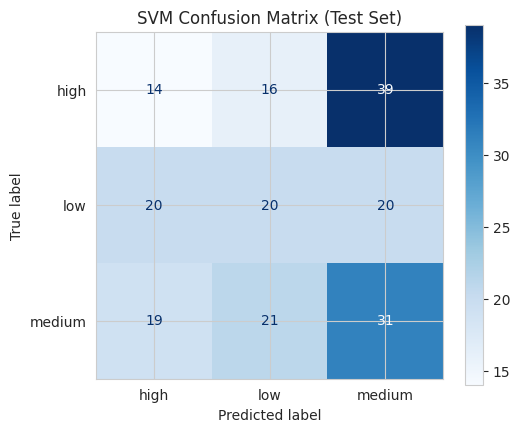

In [17]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title('SVM Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()


## 8. Putting the SVM score in context

A single accuracy number is hard to interpret on its own. Here we compare the tuned SVM
against the naive baseline and against a Random Forest (which can pick up non-linear,
non-smooth patterns the SVM's kernel might miss).

                       Model  Accuracy  F1 (macro)
0  Baseline (majority class)     0.355    0.174662
1                  Tuned SVM     0.325    0.318827
2              Random Forest     0.335    0.325707


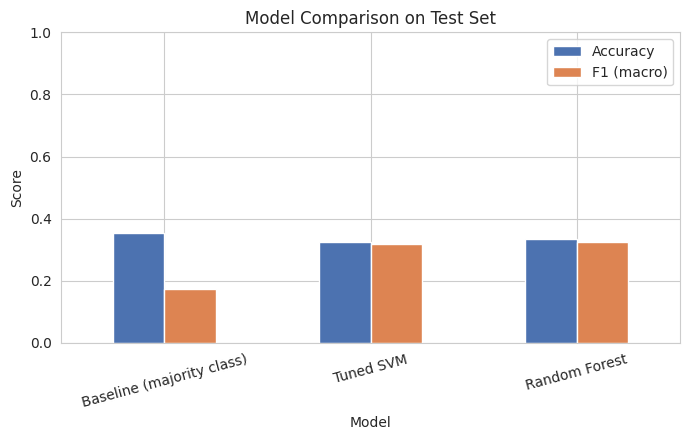

In [18]:
rf_model = RandomForestClassifier(n_estimators=500, max_depth=6, random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Model': ['Baseline (majority class)', 'Tuned SVM', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, dummy_pred),
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'F1 (macro)': [
        f1_score(y_test, dummy_pred, average='macro'),
        f1_score(y_test, y_pred, average='macro'),
        f1_score(y_test, rf_pred, average='macro')
    ]
})
print(comparison)

comparison.set_index('Model').plot(kind='bar', figsize=(7, 4.5), color=['#4C72B0', '#DD8452'])
plt.title('Model Comparison on Test Set')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


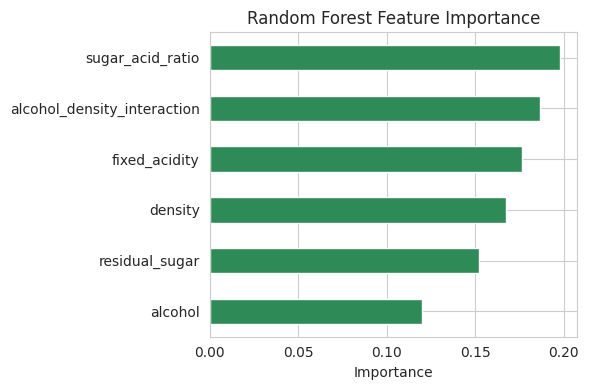

In [19]:
# Random Forest feature importance — useful diagnostic even though the RF doesn't
# outperform the baseline by much (see README for the full explanation).
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values()
plt.figure(figsize=(6, 4))
importances.plot(kind='barh', color='seagreen')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 9. Result

The tuned SVM and Random Forest both land close to the majority-class baseline. Given how
much the box plots and correlation matrix in Section 4 overlap across classes, this indicates
the four physicochemical features in this particular dataset carry very little signal about
`quality_label` — no amount of extra tuning or feature engineering can manufacture a
relationship that isn't in the data. See the README for a fuller discussion and suggestions
for next steps (e.g. checking the data source, or adding more chemically meaningful features
such as pH, sulphates, or volatile acidity if available).

## 10. Reusable prediction function

In [20]:
def predict_wine_quality(fixed_acidity, residual_sugar, alcohol, density):
    """Predict the quality label for a single wine sample."""
    sugar_acid_ratio = residual_sugar / fixed_acidity
    alcohol_density_interaction = alcohol * density

    features = pd.DataFrame([{
        'fixed_acidity': fixed_acidity,
        'residual_sugar': residual_sugar,
        'alcohol': alcohol,
        'density': density,
        'sugar_acid_ratio': sugar_acid_ratio,
        'alcohol_density_interaction': alcohol_density_interaction
    }])

    scaled = scaler.transform(features)
    prediction = svm_model.predict(scaled)
    label = le.inverse_transform(prediction)[0]
    print(f"Predicted wine quality: {label}")
    return label

# Example 1: high acidity and alcohol
predict_wine_quality(9.3, 6.4, 13.6, 1.0005)

# Example 2: lower sugar and alcohol
predict_wine_quality(11.6, 0.9, 8.2, 0.9935)


Predicted wine quality: high
Predicted wine quality: medium


In [21]:
# Save the trained model and scaler for reuse outside this notebook
import joblib
joblib.dump(svm_model, 'svm_wine_quality_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(le, 'label_encoder.joblib')
print("Saved: svm_wine_quality_model.joblib, scaler.joblib, label_encoder.joblib")


Saved: svm_wine_quality_model.joblib, scaler.joblib, label_encoder.joblib
